(lq_bewley_complete_markets)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# 不完全市场与完全市场下的消费平滑

```{contents} Contents
:depth: 2
```

```{index} single: LQ Permanent Income Model; cross section
```

```{index} single: Bewley Model
```

```{index} single: Complete Markets
```

## 概述

本讲研究当众多消费者各自求解 LQ 永久收入问题时，消费的截面分布如何演化。

这是关于 LQ 永久收入模型的四讲中的第二讲，直接建立在 {doc}`lq_permanent_income` 的基础之上。

我们首先说明，个体消费中的单位根会导致消费的截面方差随时间线性增长。

然后，我们遵循 {cite:t}`Bewley1977`，将个体消费者嵌入到一个具有连续统消费者的**封闭经济**中，并展示总名义利率 $R = \beta^{-1}$ 如何作为均衡结果出现。

最后，我们用一整套完备的阿罗证券替代单一的无风险债券，并展示完全市场如何实现一个时不变的消费截面分布。

第三讲 {doc}`lq_robust_smoothing` 放松了消费者完全信任其收入模型的假设。

第四讲 {doc}`lq_robust_bewley` 回到本讲的贝利经济体，并在其中引入了对该模型信任程度各不相同的消费者。

让我们从一些导入开始。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import inv
import matplotlib as mpl  # i18n
FONTPATH = "fonts/SourceHanSerifSC-SemiBold.otf"  # i18n
mpl.font_manager.fontManager.addfont(FONTPATH)  # i18n
mpl.rcParams['font.family'] = ['Source Han Serif SC']  # i18n


## 简要回顾

我们回顾一下 {doc}`lq_permanent_income` 中的要点。

一个具有二次效用、贴现因子 $\beta$、并可获得总回报为 $R = \beta^{-1}$ 的无风险债券的消费者，面临如下的禀赋过程

$$
\begin{aligned}
z_{t+1} &= \check{A}\, z_t + \check{C}\, w_{t+1} \\
y_t &= \check{G}\, z_t
\end{aligned}
$$ (eq:pi-endowment)

其中 $w_{t+1}$ 是均值为零、协方差矩阵为单位阵的 IID 过程。

最优消费函数将消费表示为总财富的 $r/(1+r) = (1-\beta)$ 倍，

$$
c_t = (1-\beta)\!\left[\check{G}(I-\beta\check{A})^{-1} z_t - b_t\right]
$$ (eq:pi-ccf)

该模型具有一个状态空间表示，其中状态为当前消费 $c_t$ 和外生禀赋状态 $z_t$：

$$
\begin{aligned}
c_{t+1} &= c_t + (1-\beta)\,\check{G}(I-\beta\check{A})^{-1}\check{C}\, w_{t+1} \\
b_t &= \check{G}(I-\beta\check{A})^{-1} z_t - \frac{1}{1-\beta}\,c_t \\
y_t &= \check{G}\, z_t \\
z_{t+1} &= \check{A}\, z_t + \check{C}\, w_{t+1}
\end{aligned}
$$ (eq:pi-crep)

消费是一个**随机游走**：其一阶差分是 IID 新息 $h\, w_{t+1}$，其中
$h = (1-\beta)\,\check{G}(I-\beta\check{A})^{-1}\check{C}$。

在整个讲座中，我们使用 {doc}`lq_permanent_income` 中的双因子禀赋 $y_t = z_{1t} + z_{2t}$，其中 $z_{1t}$ 是永久成分，$z_{2t}$ 是纯粹的暂时成分，因此 $\check{A} = \mathrm{diag}(1,0)$ 且 $\check{C} = \mathrm{diag}(\sigma_1,\sigma_2)$。

下面的代码单元重现了校准值和关键矩阵。

In [2]:
# 参数
β = 0.95       # 贴现因子（因此 R = 1/β）
σ1 = 0.15      # 永久冲击的标准差
σ2 = 0.30      # 暂时冲击的标准差

# 双因子禀赋
A_check = np.array([[1.0, 0.0],
                    [0.0, 0.0]])
C_check = np.array([[σ1, 0.0],
                    [0.0, σ2]])
G_check = np.array([[1.0, 1.0]])

# 关键矩阵 M = G(I - βA)^{-1}
IbA = np.eye(2) - β * A_check
M = G_check @ inv(IbA)   # 形状 (1, 2)

## 消费截面的扩散

```{index} single: Cross-Section Distributions; consumption
```

消费中的单位根（表示 {eq}`eq:pi-crep`）导致消费的**截面方差**随时间线性增长。

考虑一个连续统的*事前*相同的家庭，均在 $t = 0$ 时出生。

所有家庭 $i$ 具有相同的偏好。

他们都面临相同形式的非金融收入随机过程


$$
y_t^i = g( w_t^i, w_{t-1}^i, \ldots, w_0^i; z_0^i),
$$ (eq:gstochpro)

虽然所有消费者都面临相同的 $g$ 过程，但他们对**特有的**冲击序列 $\{w_{t}^i\}_{t=0}^\infty$ 有不同的、统计独立的实现。

设所有家庭从相同的初始条件 $c_0^i = c_0$ 和 $z_0^i$ 出发。

由 {eq}`eq:pi-crep`，家庭 $i$ 的消费遵循

$$
c_{t+1}^i = c_t^i + h\, w_{t+1}^i, \qquad h = (1-\beta)\,\check{G}(I-\beta\check{A})^{-1}\check{C}
$$

由于 $\{w^i_{t}\}$ 的实现在各主体之间独立，

$$
\mathbb{E}_0\bigl(c_t^i - c_0^i\bigr)^2 = t\, h h^\top
$$ (eq:varspread)

在双因子模型中，$h$ 是一个 $1 \times 2$ 的行向量，因此 $hh^\top$ 是一个正标量，等于
$\sigma_1^2 + (1-\beta)^2\sigma_2^2$。

消费的截面方差按 $t$ 增长。

findfont: Failed to find font weight normal, now using 600.
findfont: Failed to find font weight normal, now using 600.


findfont: Failed to find font weight normal, now using 600.


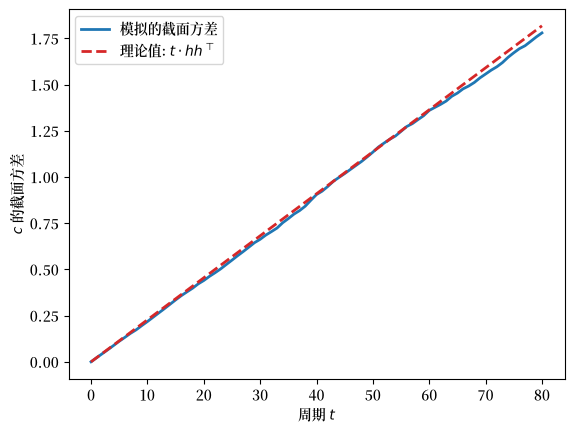

In [3]:
# 模拟截面扩散
rng = np.random.default_rng(42)
N = 5000       # 主体数量
T_sim = 80         # 周期数

h_vec = (1 - β) * (M @ C_check)   # 形状 (1, 2)，然后展平
h_vec = h_vec.flatten()            # h = [h1, h2]

c = np.zeros((N, T_sim + 1))       # 消费路径
# 将所有主体初始化为 c_0 = 0（去均值）
for t in range(T_sim):
    eps = rng.standard_normal((N, 2))    # N 次二维冲击抽样
    dc = eps @ h_vec              # 形状 (N,)
    c[:, t+1] = c[:, t] + dc

# 每个日期的截面方差
var_c = np.var(c, axis=0)
theory = np.arange(T_sim + 1) * np.dot(h_vec, h_vec)

fig, ax = plt.subplots()
ax.plot(var_c, label='模拟的截面方差', lw=2)
ax.plot(theory, label=r'理论值: $t \cdot h h^\top$',
        linestyle='--', color='C3', lw=2)
ax.set_xlabel('周期 $t$')
ax.set_ylabel('$c$ 的截面方差')
ax.legend()
plt.show()

## 借款人与贷款人经济

```{index} single: Bewley Model
```

到目前为止，我们设定 $R = \beta^{-1}$，并将其视为在模型外部决定的（"小型开放经济"）。

遵循 {cite:t}`Bewley1977` 的思想，我们可以构建一个**封闭经济**，其中
$R = \beta^{-1}$ 是一个**均衡结果**。

一个测度为 1 的连续统消费者，以 $i \in [0,1]$ 为索引，交易一种价格为 $\beta$ 的无风险单期债券。

所有消费者具有相同的偏好和相同的随机收入过程 {eq}`eq:gstochpro`，但面临**特有的**非金融收入冲击过程的实现。

初始债券头寸为零：对所有 $i$ 都有 $b_0^i = 0$。

初始禀赋状态 $z_0^i$ 是来自同一初始分布的独立抽样。

由于永久成分 $z_{1t}$ 具有单位根，过程 {eq}`eq:pi-endowment` 没有平稳分布，因此在下面的模拟中，我们抽取永久成分 $z_{10}^i \sim N(0,1)$，并从其平稳分布中抽取暂时成分 $z_{20}^i \sim N(0,\sigma_2^2)$。

由 {eq}`eq:pi-ccf`，当 $b_0^i = 0$ 时，主体 $i$ 在时刻 0 的消费为

$$
c_0^i = (1-\beta)\,\check{G}(I-\beta\check{A})^{-1} z_0^i
$$ (eq:c_null)

对于 $t \geq 1$，由 {eq}`eq:pi-crep`：

$$
c_{t+1}^i = c_t^i + h\, w_{t+1}^i, \qquad h = (1-\beta)\,\check{G}(I-\beta\check{A})^{-1}\check{C}
$$ (eq:c_future)

设 $Y$ 表示非金融收入截面平均值的平稳均值。

对所有主体积分 {eq}`eq:c_null`：

$$
\int_0^1 c_0^i\, di = (1-\beta)\sum_{j=0}^{\infty}\beta^j \mathbb{E}_0\!\int_0^1 y_j^i\, di = Y
$$ (eq:c_marketclear_0)

因为连续统的特有冲击平均为零。

对于未来的周期，对 {eq}`eq:c_future` 积分：

$$
\int_0^1 c_{t+1}^i\, di = \int_0^1 c_t^i\, di + h\!\underbrace{\int_0^1 w_{t+1}^i\, di}_{=\,0} = Y
$$

商品市场在每个日期都以*恒定*的总消费 $Y$ 出清。

债券市场每期以零净供给出清。

因此，$R = \beta^{-1}$ 是一个均衡结果。

 

虽然消费的截面均值是恒定的，但截面*方差*根据 {eq}`eq:varspread` 无界增长。

禀赋抽样 $z_0^i$ 的初始差异造成了消费水平的永久差异。

findfont: Failed to find font weight normal, now using 600.


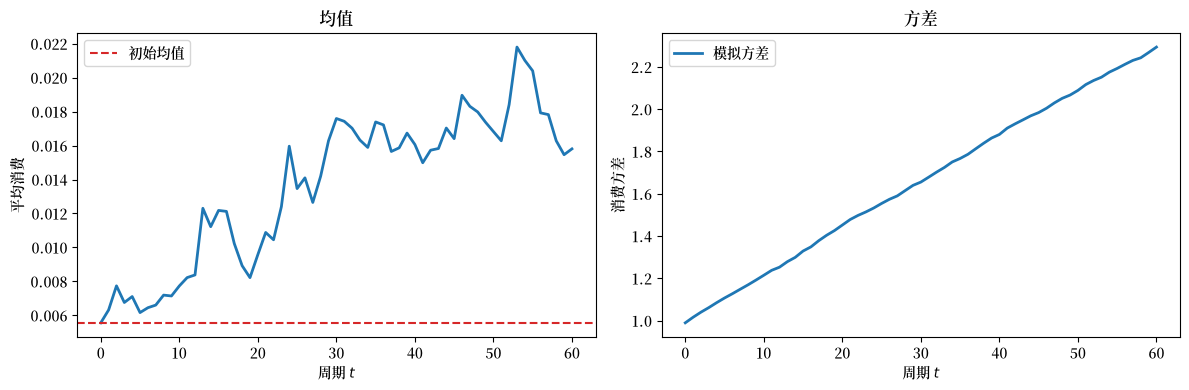

In [4]:
# 通过模拟验证 Bewley 市场出清
# 在线计算均值和方差以避免存储所有路径。
rng = np.random.default_rng(0)
N_bew = 10000    # 主体数量
T_bew = 60

# 为模拟抽取初始状态。
z0_i = rng.standard_normal((N_bew, 2)) * np.array([1.0, σ2])
c0_i = ((1 - β) * (M @ z0_i.T)).flatten()   # 形状 (N_bew,)

# 在各主体间传播消费。
mean_c = np.zeros(T_bew + 1)
var_c2 = np.zeros(T_bew + 1)
mean_c[0] = c0_i.mean()
var_c2[0] = c0_i.var()

c_now = c0_i.copy()
for t in range(T_bew):
    eps = rng.standard_normal((N_bew, 2))
    c_now = c_now + eps @ h_vec
    mean_c[t + 1] = c_now.mean()
    var_c2[t + 1] = c_now.var()

# 在下面重用初始消费。
c_bew_t0 = c0_i

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(mean_c, lw=2, color='C0')
axes[0].axhline(mean_c[0], linestyle='--', color='C3', label='初始均值')
axes[0].set_xlabel('周期 $t$')
axes[0].set_ylabel('平均消费')
axes[0].set_title('均值')
axes[0].legend()

axes[1].plot(var_c2, lw=2, color='C0', label='模拟方差')
axes[1].set_xlabel('周期 $t$')
axes[1].set_ylabel('消费方差')
axes[1].set_title('方差')
axes[1].legend()
fig.tight_layout()
plt.show()

由于每个消费者都不喜欢消费随时间的波动，每个消费者都会更倾向于一个完全平滑的消费流 $c_t^i = c_0^i$（对所有 $t$）。

这样的配置是可行的，因为收入的截面平均值是恒定的。

下一节描述一个支持这一结果的完全市场配置。

## 完全市场下的消费平滑

```{index} single: Complete Markets; Arrow securities
```

我们用一整套完备的**阿罗证券**替代单一债券。

预算约束变为

$$
c_t + b_{t-1}(z_t) = \int q(z_{t+1}|z_t)\, b_t(z_{t+1})\, dz_{t+1} + y_t
$$ (eq:CMbudget)

其中 $q(z_{t+1}|z_t)$ 是单期或有债权的定价核，而
$b_t(z_{t+1})$ 是家庭在 $t$ 时刻选择的阿罗证券组合。

我们猜测（并验证）均衡定价核为

$$
q(z_{t+1}|z_t) = \beta\,\phi(z_{t+1}|z_t)
$$ (eq:kernel)

其中 $\phi(z_{t+1}|z_t)$ 是 $z$ 的转移密度。

该核将单期无风险债券定价为 $\beta$，因此 $R = \beta^{-1}$，这与不完全市场均衡一致。

我们推测均衡为每个消费者 $i$ 提供*恒定*的消费水平：

$$
c_t^i = \bar{c}^i = c_0^i, \quad \forall\, t \geq 0
$$ (eq:constcons)

其中 $c_0^i = (1-\beta)\,\check{G}(I-\beta\check{A})^{-1} z_0^i$ 是消费者在不完全市场经济中时刻 0 的消费。

支持恒定消费的或有债务为

$$
b_{t-1}(z_t) = \check{G}(I-\beta\check{A})^{-1} z_t - \frac{1}{1-\beta}\,\bar{c}^i \;\equiv\; b(z_t, \bar{c}^i)
$$ (eq:cmdebt)

注意，负债水平仅取决于当前的马尔可夫状态 $z_t$，而*不*取决于先前状态的历史。

这种历史依赖性的缺失反映了完全市场下实现的**完全风险分担**。

将定价核 {eq}`eq:kernel` 和组合推测 {eq}`eq:cmdebt` 代入预算约束 {eq}`eq:CMbudget`，并使用重复期望法则，可以确认预算约束在每个状态和周期都简化为 $c_t = \bar{c}^i$。

在完全市场下，消费的截面分布是**时不变的**。

消费者 $i$ 在消费分布中的排名永远固定不变。

一次幸运的初始抽样 $z_0^i$ 表现为在所有未来状态中持续较高的消费 $\bar{c}^i$ 和较低的负债 $b(z_t^i, \bar{c}^i)$。

这一结果与不完全市场 Bewley 经济中发生的情况形成对比，在后者中，消费的截面方差无界增长。

findfont: Failed to find font weight normal, now using 600.


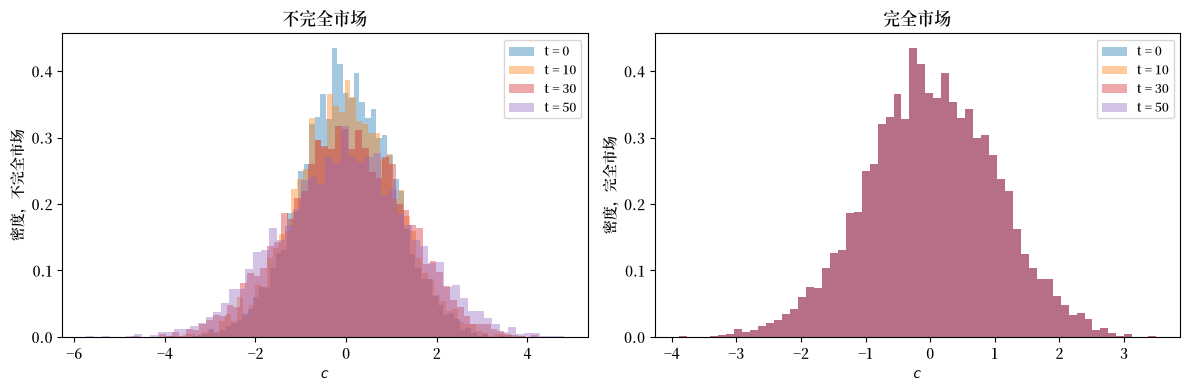

In [5]:
# 完全与不完全消费分布
rng = np.random.default_rng(1)
N_cm = 5000
T_cm = 50

# 初始消费抽样（与 Bewley 经济相同）
c0_cm = c_bew_t0[:N_cm]

# 不完全市场：消费演化（随机游走）
c_inc = np.zeros((N_cm, T_cm + 1))
c_inc[:, 0] = c0_cm
for t in range(T_cm):
    eps = rng.standard_normal((N_cm, 2))
    c_inc[:, t+1] = c_inc[:, t] + eps @ h_vec

# 完全市场：消费保持恒定
c_comp = np.tile(c0_cm[:, np.newaxis], T_cm + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for t_plot, color in zip([0, 10, 30, 50], ['C0', 'C1', 'C3', 'C4']):
    axes[0].hist(c_inc[:, t_plot], bins=60, alpha=0.4,
                 label=f't = {t_plot}', color=color, density=True)
axes[0].set_xlabel('$c$')
axes[0].set_ylabel('密度，不完全市场')
axes[0].set_title('不完全市场')
axes[0].legend(fontsize=9)

for t_plot, color in zip([0, 10, 30, 50], ['C0', 'C1', 'C3', 'C4']):
    axes[1].hist(c_comp[:, t_plot], bins=60, alpha=0.4,
                 label=f't = {t_plot}', color=color, density=True)
axes[1].set_xlabel('$c$')
axes[1].set_ylabel('密度，完全市场')
axes[1].set_title('完全市场')
axes[1].legend(fontsize=9)
fig.tight_layout()
plt.show()

```{note}
在**完全市场**下，直方图在所有 $t$ 上保持不变（分布完美重合），而在**不完全市场**下，分布随时间扩散。
```

到目前为止，消费者完全信任其随机收入模型。

在 {doc}`lq_robust_smoothing` 中，我们放松这一假设，让消费者寻求对合理的模型误设具有稳健性的决策规则。

{doc}`lq_robust_bewley` 随后回到本讲座所研究的 Bewley 经济，并说明具有不同模型误设担忧程度的消费者截面可以精确再现本讲座的均衡。

最优稳健规则采用与上述规则相同的形式，但基于一个扭曲的收入过程模型，该模型看起来比近似模型更具持续性。

## 练习

```{exercise-start}
:label: lqbcm_ex1
```

本练习研究耐心程度如何决定消费截面扩散的速度。

由 {eq}`eq:varspread`，消费的截面方差每期增长 $h h^\top = \sigma_1^2 + (1-\beta)^2\sigma_2^2$。

1. 对 $\beta \in \{0.90, 0.95, 0.99\}$ 计算这个每期增长率，并分别报告永久成分和暂时成分的贡献。

2. 通过模拟确认，对于 $\beta = 0.95$，截面方差以预测的速率线性增长。

3. 解释为什么增加 $\beta$ 会减慢由暂时冲击引起的扩散，但保持永久冲击的贡献不变。

```{exercise-end}
```

```{solution-start} lqbcm_ex1
:class: dropdown
```

这是一个解答：

In [6]:
for b in (0.90, 0.95, 0.99):
    perm = σ1**2
    tran = (1 - b)**2 * σ2**2
    print(f"β = {b}:  growth = {perm + tran:.5f}  "
          f"(permanent {perm:.5f}, transitory {tran:.5f})")

β = 0.9:  growth = 0.02340  (permanent 0.02250, transitory 0.00090)
β = 0.95:  growth = 0.02272  (permanent 0.02250, transitory 0.00023)
β = 0.99:  growth = 0.02251  (permanent 0.02250, transitory 0.00001)


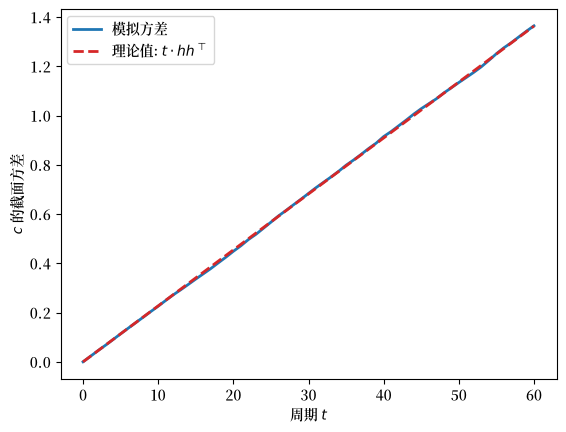

In [7]:
rng = np.random.default_rng(7)
N, T_sim = 20000, 60
hh = float(h_vec @ h_vec)

c = np.zeros((N, T_sim + 1))
for t in range(T_sim):
    c[:, t + 1] = c[:, t] + rng.standard_normal((N, 2)) @ h_vec

var_c = c.var(axis=0)
theory = np.arange(T_sim + 1) * hh

fig, ax = plt.subplots()
ax.plot(var_c, lw=2, label='模拟方差')
ax.plot(theory, lw=2, linestyle='--', color='C3',
        label=r'理论值: $t\cdot h h^\top$')
ax.set_xlabel('周期 $t$')
ax.set_ylabel('$c$ 的截面方差')
ax.legend()
plt.show()

永久成分的贡献 $\sigma_1^2$ 不依赖于 $\beta$，因为无论耐心程度如何，永久冲击都会一比一地资本化到消费中。

暂时成分的贡献 $(1-\beta)^2\sigma_2^2$ 随着 $\beta \to 1$ 而缩小，因为更有耐心的消费者会在更长的视界上平滑暂时冲击，仅按较小的年金价值 $(1-\beta)$ 调整消费。

```{solution-end}
```

```{exercise-start}
:label: lqbcm_ex2
```

本练习对比不完全市场与完全市场下消费的截面方差。

让所有消费者从上面计算的初始消费抽样 `c_bew_t0` 出发。

1. 在不完全市场（消费是随机游走）和完全市场（消费恒定）下，计算每个日期 $t = 0, 1, \ldots, 60$ 的截面方差。

2. 将两条方差路径绘制在同一坐标轴上，并评论其差异。

```{exercise-end}
```

```{solution-start} lqbcm_ex2
:class: dropdown
```

这是一个解答：

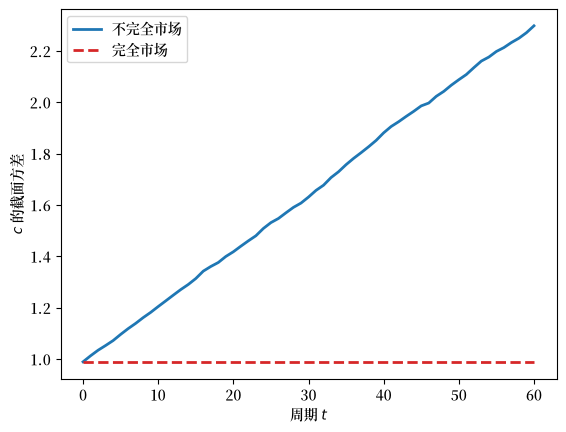

In [8]:
rng = np.random.default_rng(11)
T = 60
c0 = c_bew_t0

# 不完全市场：随机游走消费
c_inc = np.zeros((len(c0), T + 1))
c_inc[:, 0] = c0
for t in range(T):
    c_inc[:, t + 1] = c_inc[:, t] + rng.standard_normal((len(c0), 2)) @ h_vec

var_inc = c_inc.var(axis=0)
var_comp = np.full(T + 1, c0.var())   # 完全市场：消费恒定

fig, ax = plt.subplots()
ax.plot(var_inc, lw=2, label='不完全市场')
ax.plot(var_comp, lw=2, linestyle='--', color='C3', label='完全市场')
ax.set_xlabel('周期 $t$')
ax.set_ylabel('$c$ 的截面方差')
ax.legend()
plt.show()

在不完全市场下，方差无界地线性上升：每个消费者累积一个独立的消费新息随机游走。

在完全市场下，方差是平坦的：每个消费者锁定了一个恒定的消费水平 $\bar{c}^i$，因此截面分布永不改变。

```{solution-end}
```

```{exercise-start}
:label: lqbcm_ex3
```

本练习展示完全市场如何冻结每个消费者在消费分布中的*排名*。

在完全市场下，消费恒定，因此消费者在截面分布中的位置永不改变；在不完全市场下，随机游走逐渐打乱排名。

1. 从 `c_bew_t0` 出发，在两种市场结构下模拟消费路径。

2. 在每种市场结构下，计算 $t = 0$ 时的消费与后续日期 $t$ 时的消费之间的斯皮尔曼秩相关系数，并将其与 $t$ 绘制成图。

3. 解释结果。

```{exercise-end}
```

```{solution-start} lqbcm_ex3
:class: dropdown
```

这是一个解答：

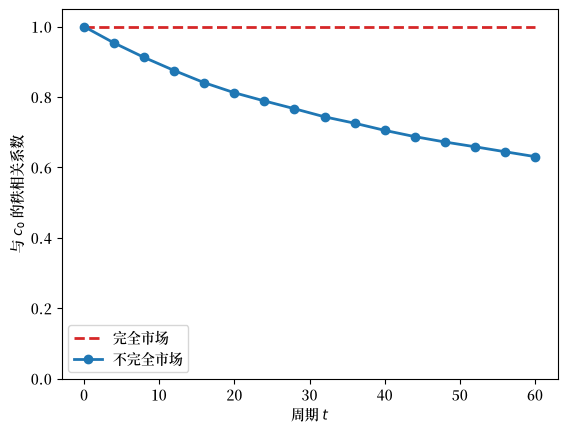

In [9]:
from scipy.stats import spearmanr

rng = np.random.default_rng(3)
T = 60
c0 = c_bew_t0

c_inc = np.zeros((len(c0), T + 1))
c_inc[:, 0] = c0
for t in range(T):
    c_inc[:, t + 1] = c_inc[:, t] + rng.standard_normal((len(c0), 2)) @ h_vec

dates = np.arange(0, T + 1, 4)
rank_inc = [spearmanr(c_inc[:, 0], c_inc[:, t]).statistic for t in dates]
rank_comp = [1.0 for _ in dates]   # 消费恒定 ⇒ 排名固定

fig, ax = plt.subplots()
ax.plot(dates, rank_comp, lw=2, linestyle='--', color='C3',
        label='完全市场')
ax.plot(dates, rank_inc, lw=2, marker='o', color='C0',
        label='不完全市场')
ax.set_xlabel('周期 $t$')
ax.set_ylabel(r'与 $c_0$ 的秩相关系数')
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

在完全市场下，秩相关系数恰好保持为 1：每个消费者永远保持由初始抽样 $z_0^i$ 决定的排名。

在不完全市场下，秩相关系数随着累积的随机游走重新洗牌谁富谁穷而衰减至零，即使每个消费者都面临相同的收入过程。

```{solution-end}
```